In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv("13_customer_segmentation.csv")

In [47]:
df.head()

,customer_id,age,income,spending_score,visits_per_month
0,CUST1000,56,120186,55,9
1,CUST1001,69,49674,80,1
2,CUST1002,46,61271,62,8
3,CUST1003,32,88688,30,6
4,CUST1004,60,126076,55,6


In [48]:
df = df.drop(columns=("customer_id"), axis=1)

In [49]:
df.head()

,age,income,spending_score,visits_per_month
0,56,120186,55,9
1,69,49674,80,1
2,46,61271,62,8
3,32,88688,30,6
4,60,126076,55,6


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               1000 non-null   int64
 1   income            1000 non-null   int64
 2   spending_score    1000 non-null   int64
 3   visits_per_month  1000 non-null   int64
dtypes: int64(4)
memory usage: 31.4 KB


In [51]:
df.isnull().sum()

age                 0
income              0
spending_score      0
visits_per_month    0
dtype: int64

In [52]:
df.describe()

,age,income,spending_score,visits_per_month
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,43.81900,83958.460000,48.681000,10.087000
std,14.99103,39293.028951,29.082659,5.543299
min,18.00000,15126.000000,1.000000,1.000000
25%,31.00000,50012.250000,22.000000,5.000000
50%,44.00000,84322.000000,48.000000,10.000000
75%,56.00000,118153.000000,74.000000,15.000000
max,69.00000,149869.000000,99.000000,19.000000


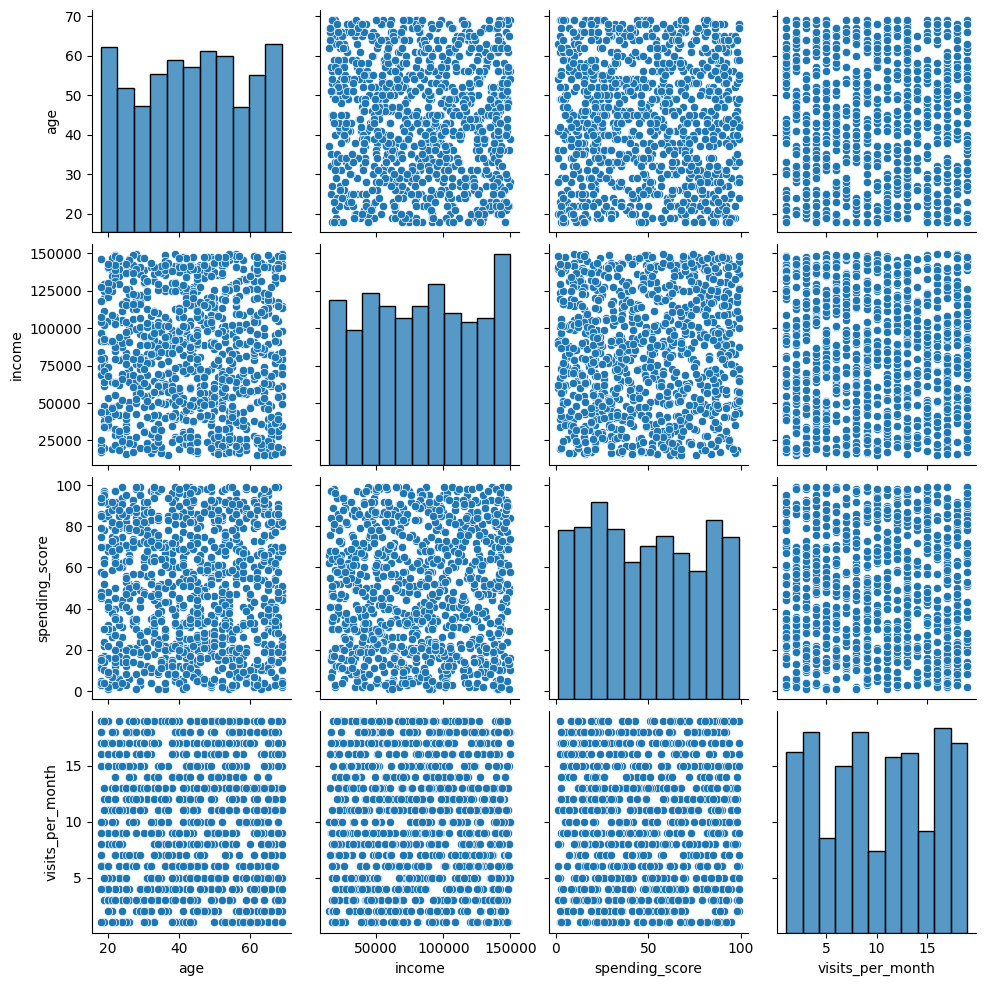

In [53]:
sns.pairplot(df)

In [54]:
features = ["age", "income", "spending_score", "visits_per_month"]

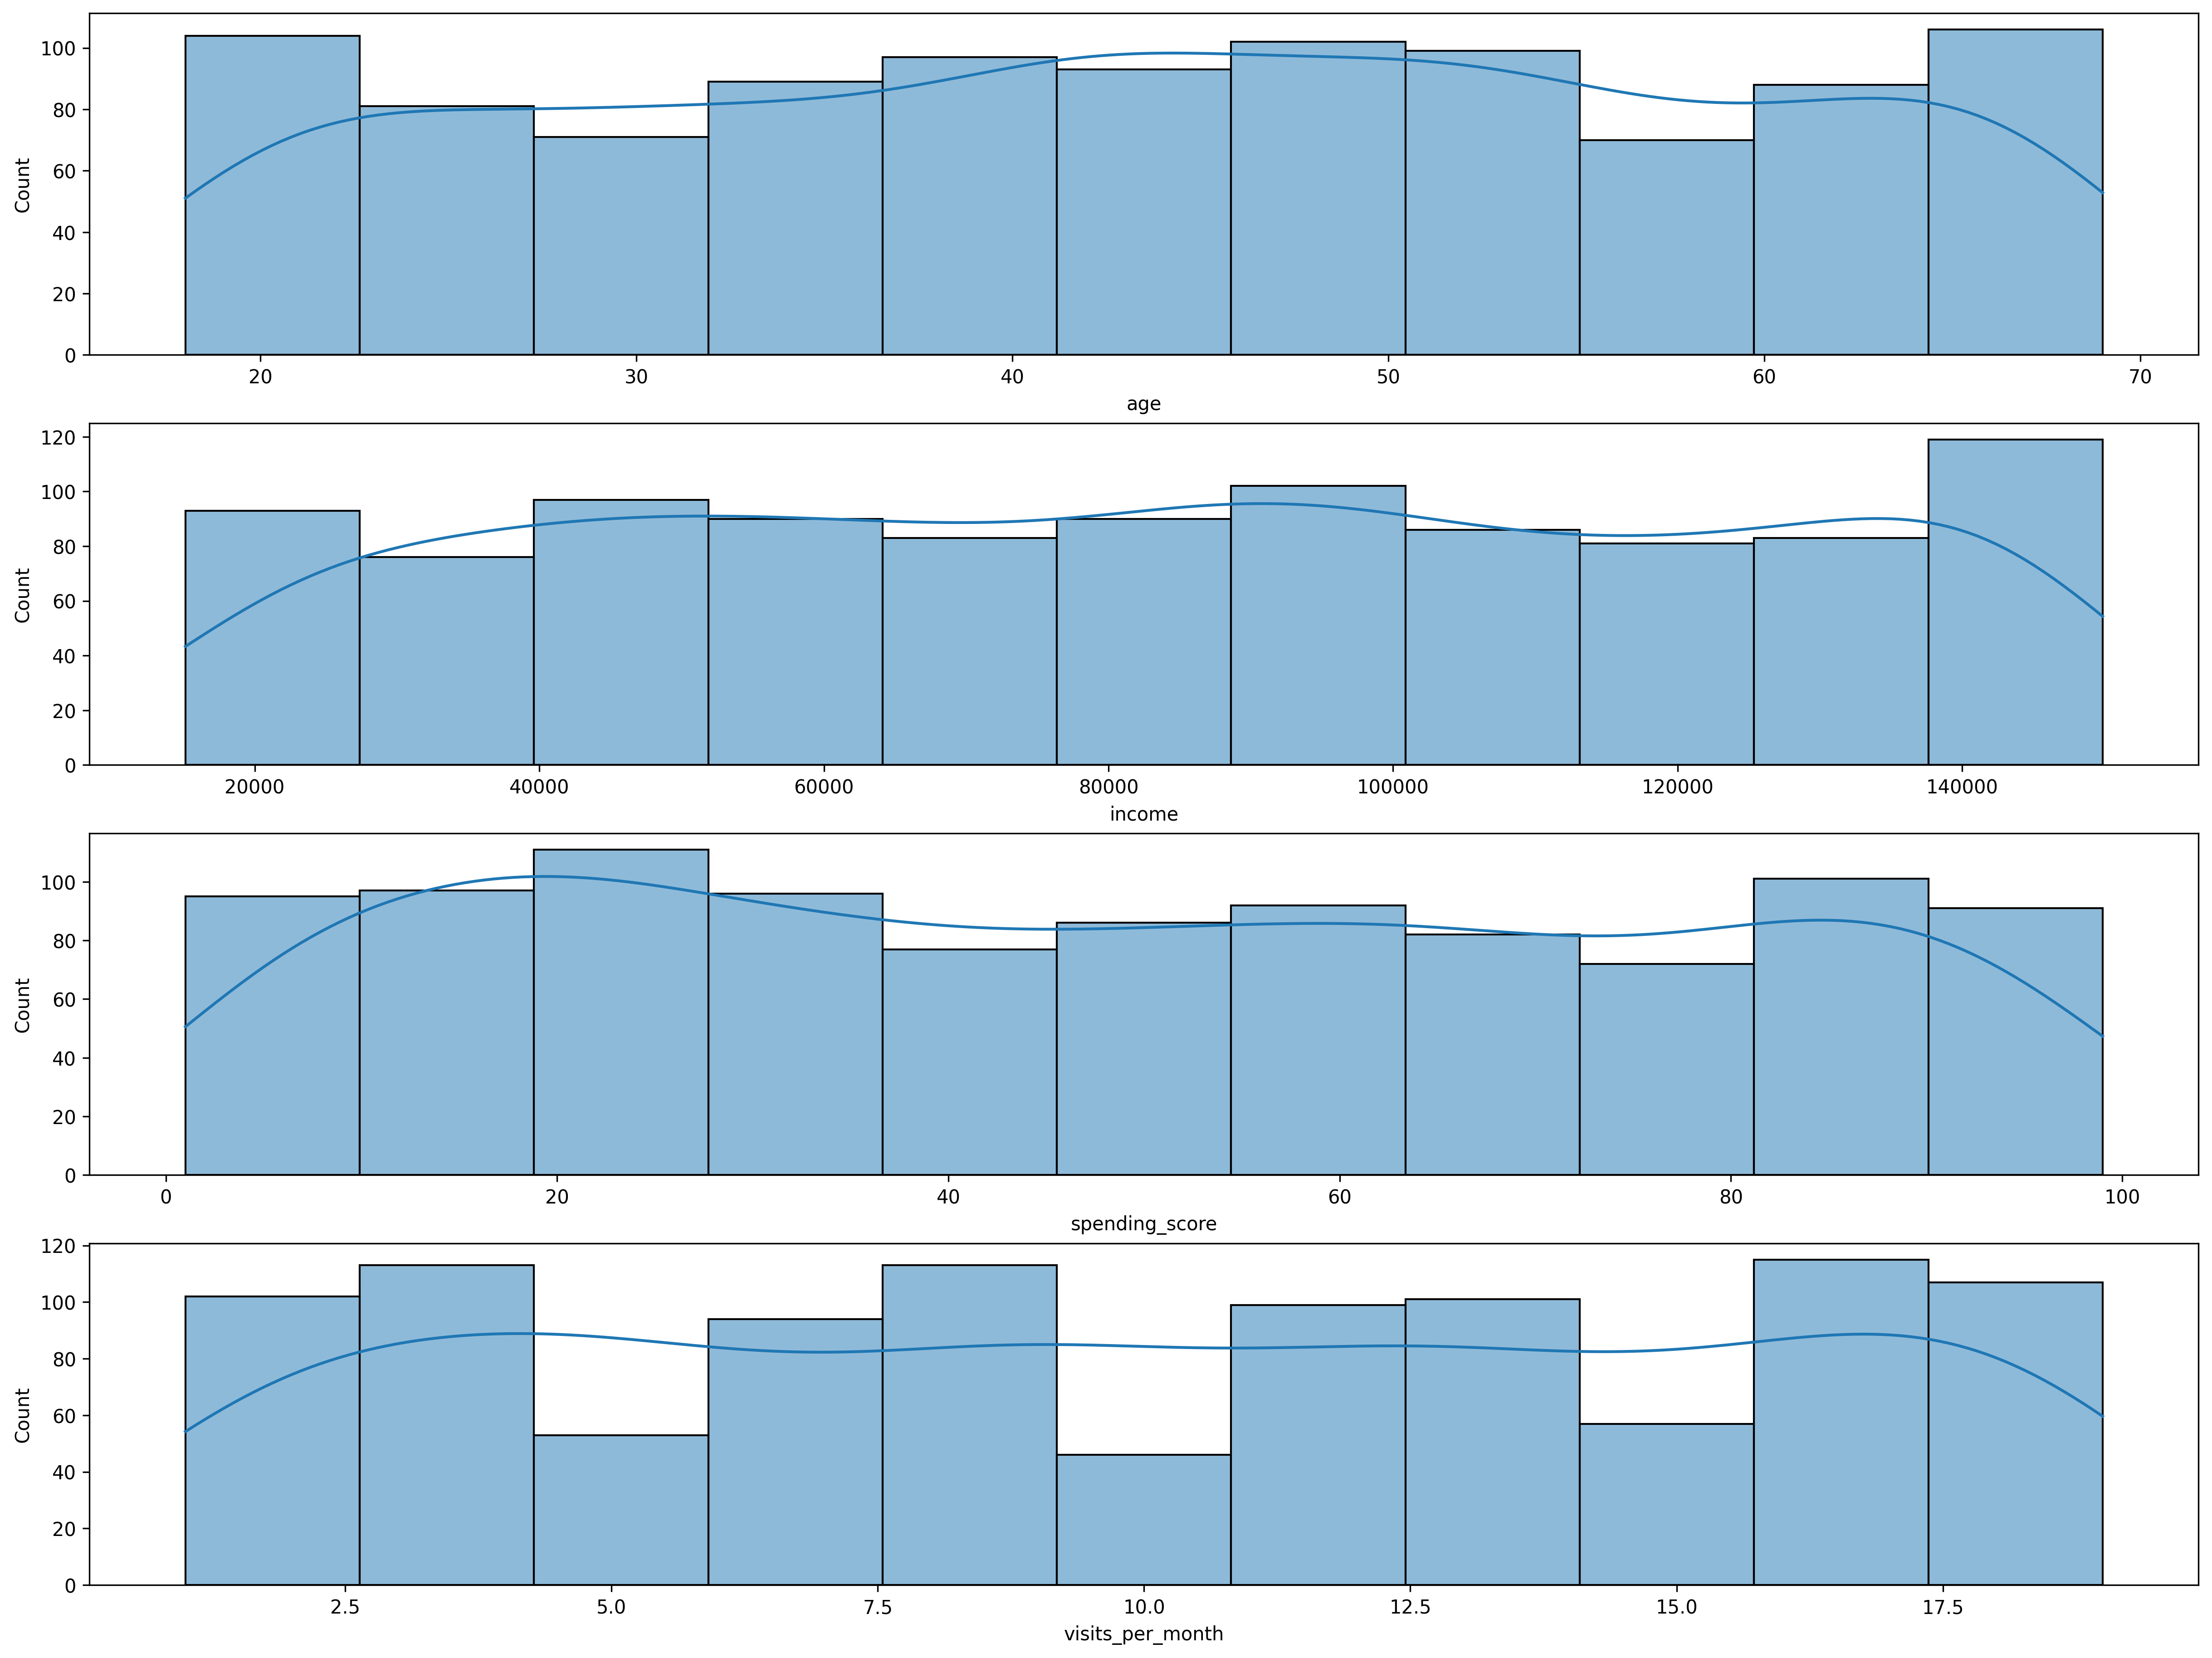

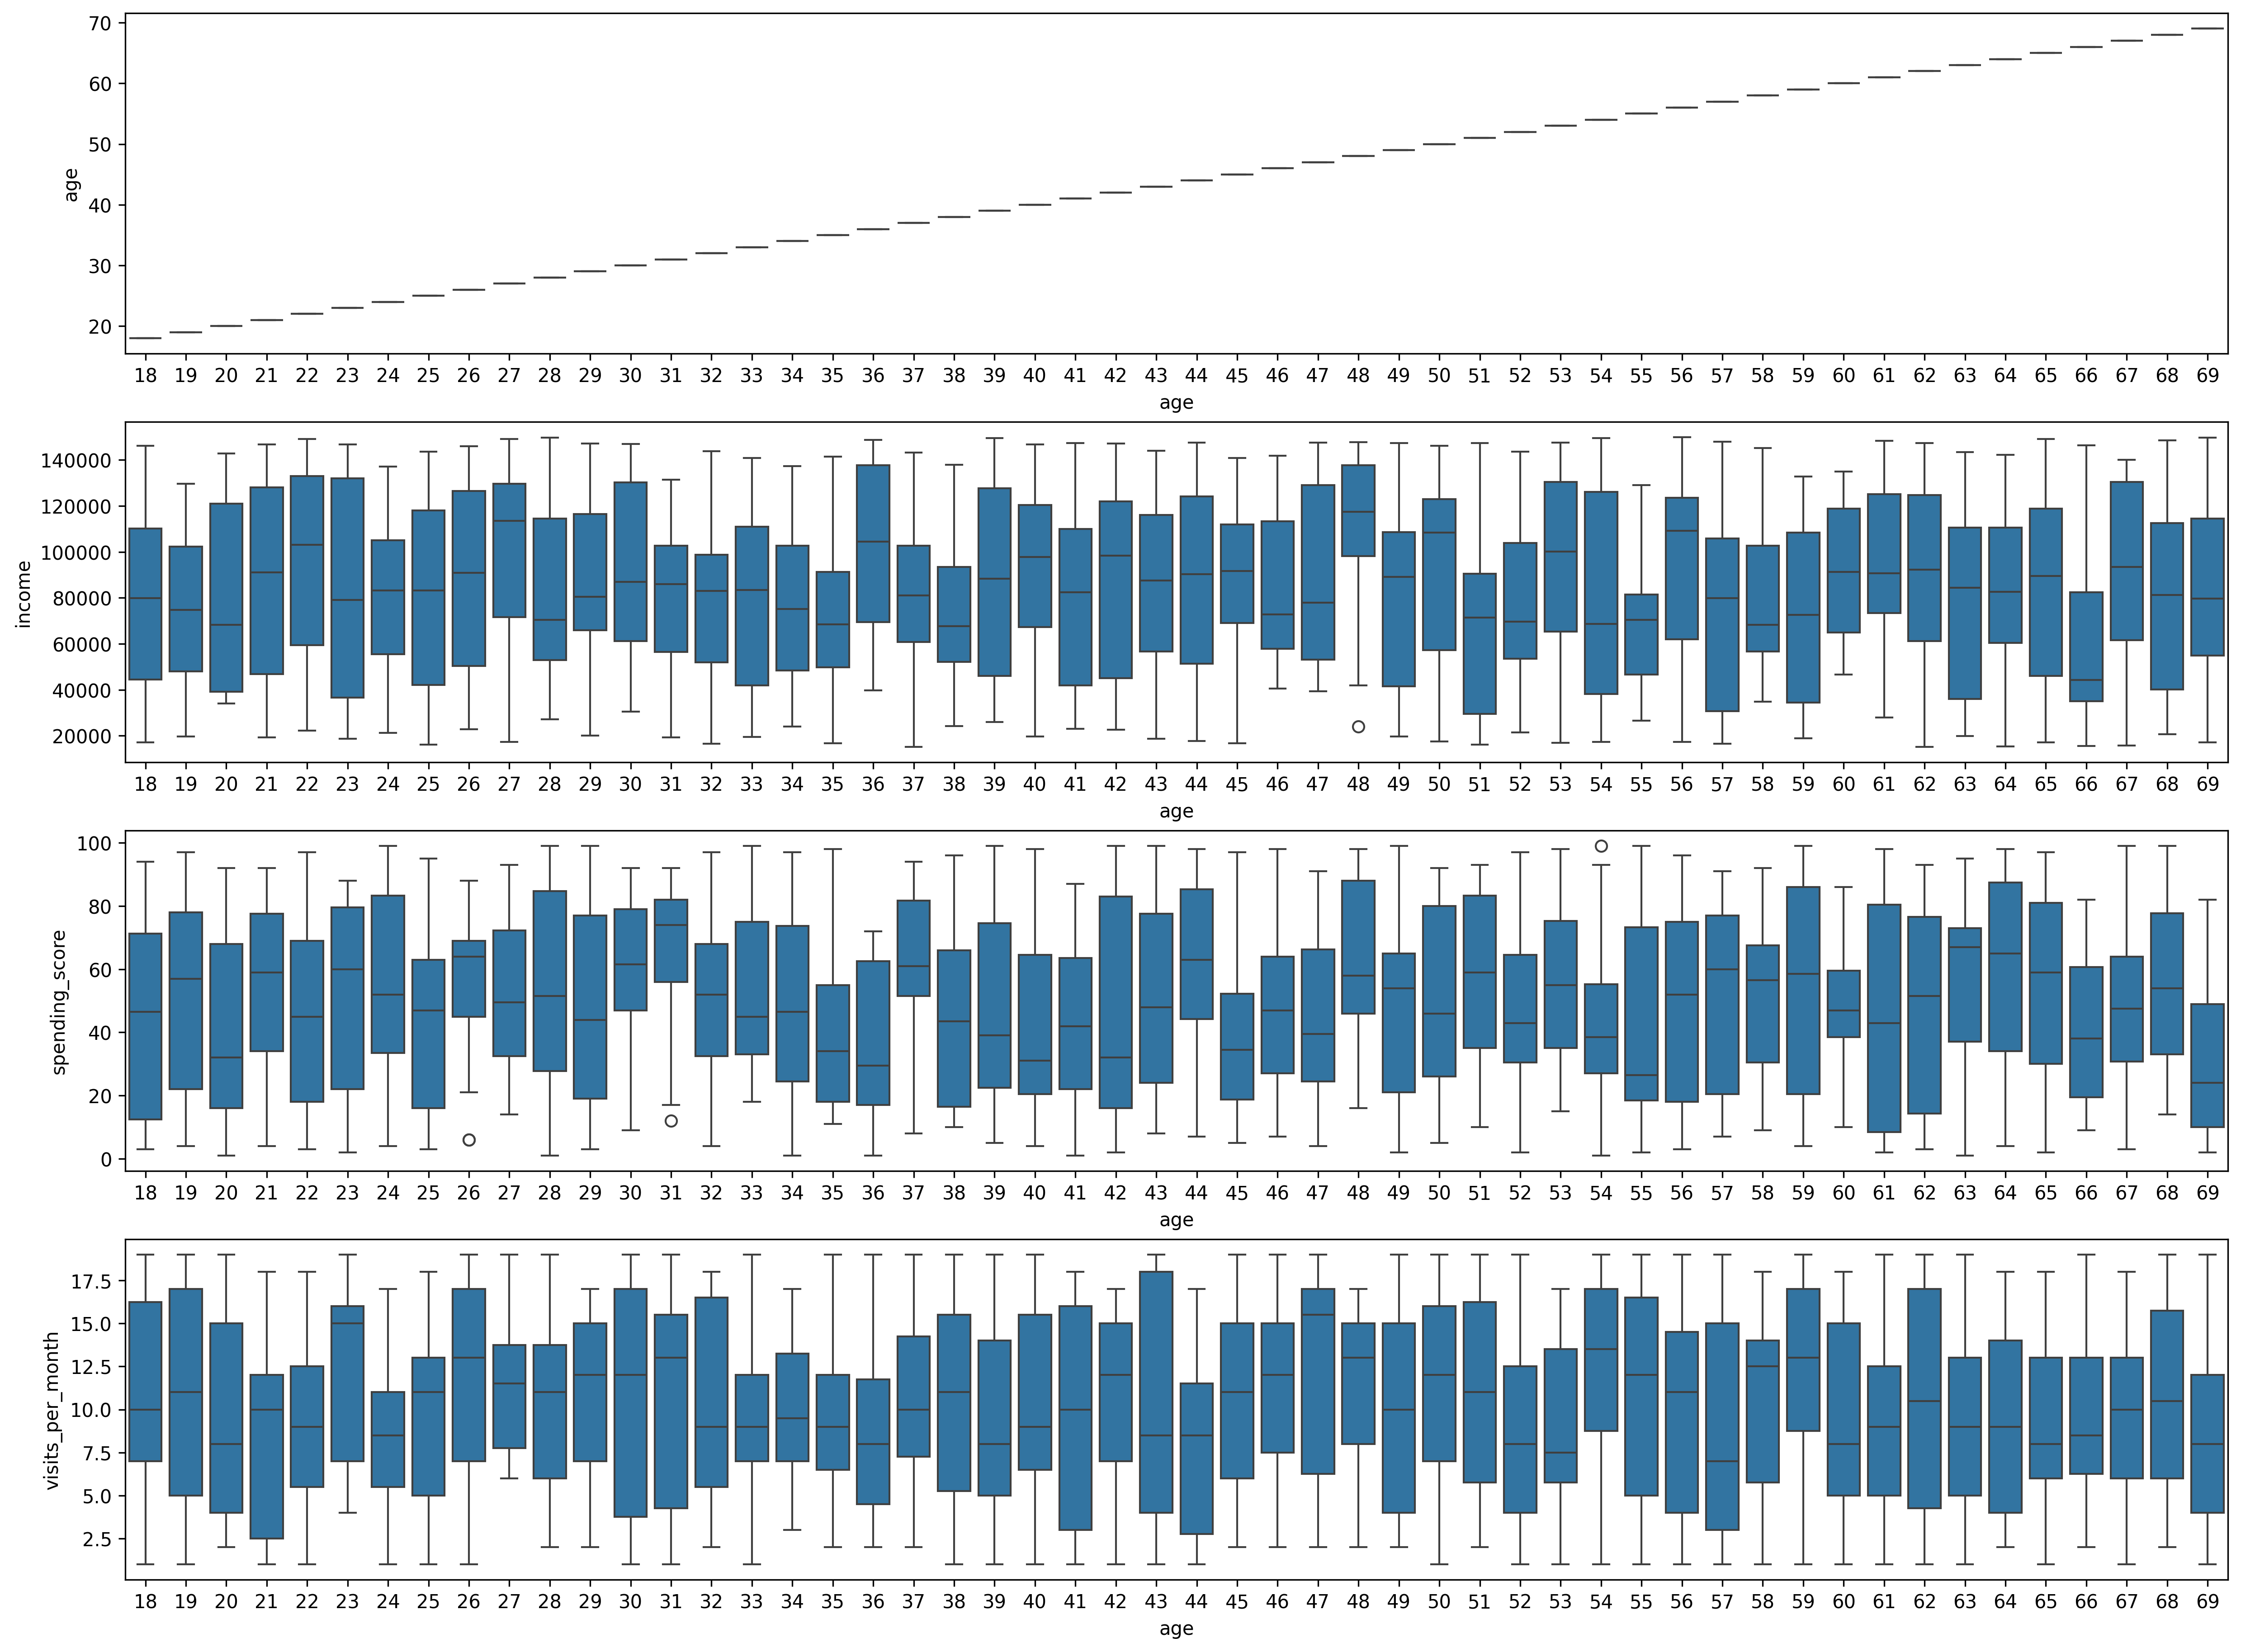

In [55]:
plt.figure(figsize=(20,15), dpi=300)

for i, var_x in enumerate(features):
    plt.subplot(4, 1, i+1)
    sns.histplot(df, x=var_x, kde=True)

plt.figure(figsize=(20,15), dpi=300)
for i, var_x in enumerate(features):
    plt.subplot(4, 1, i+1)
    sns.boxplot(df, x = "age", y = var_x)

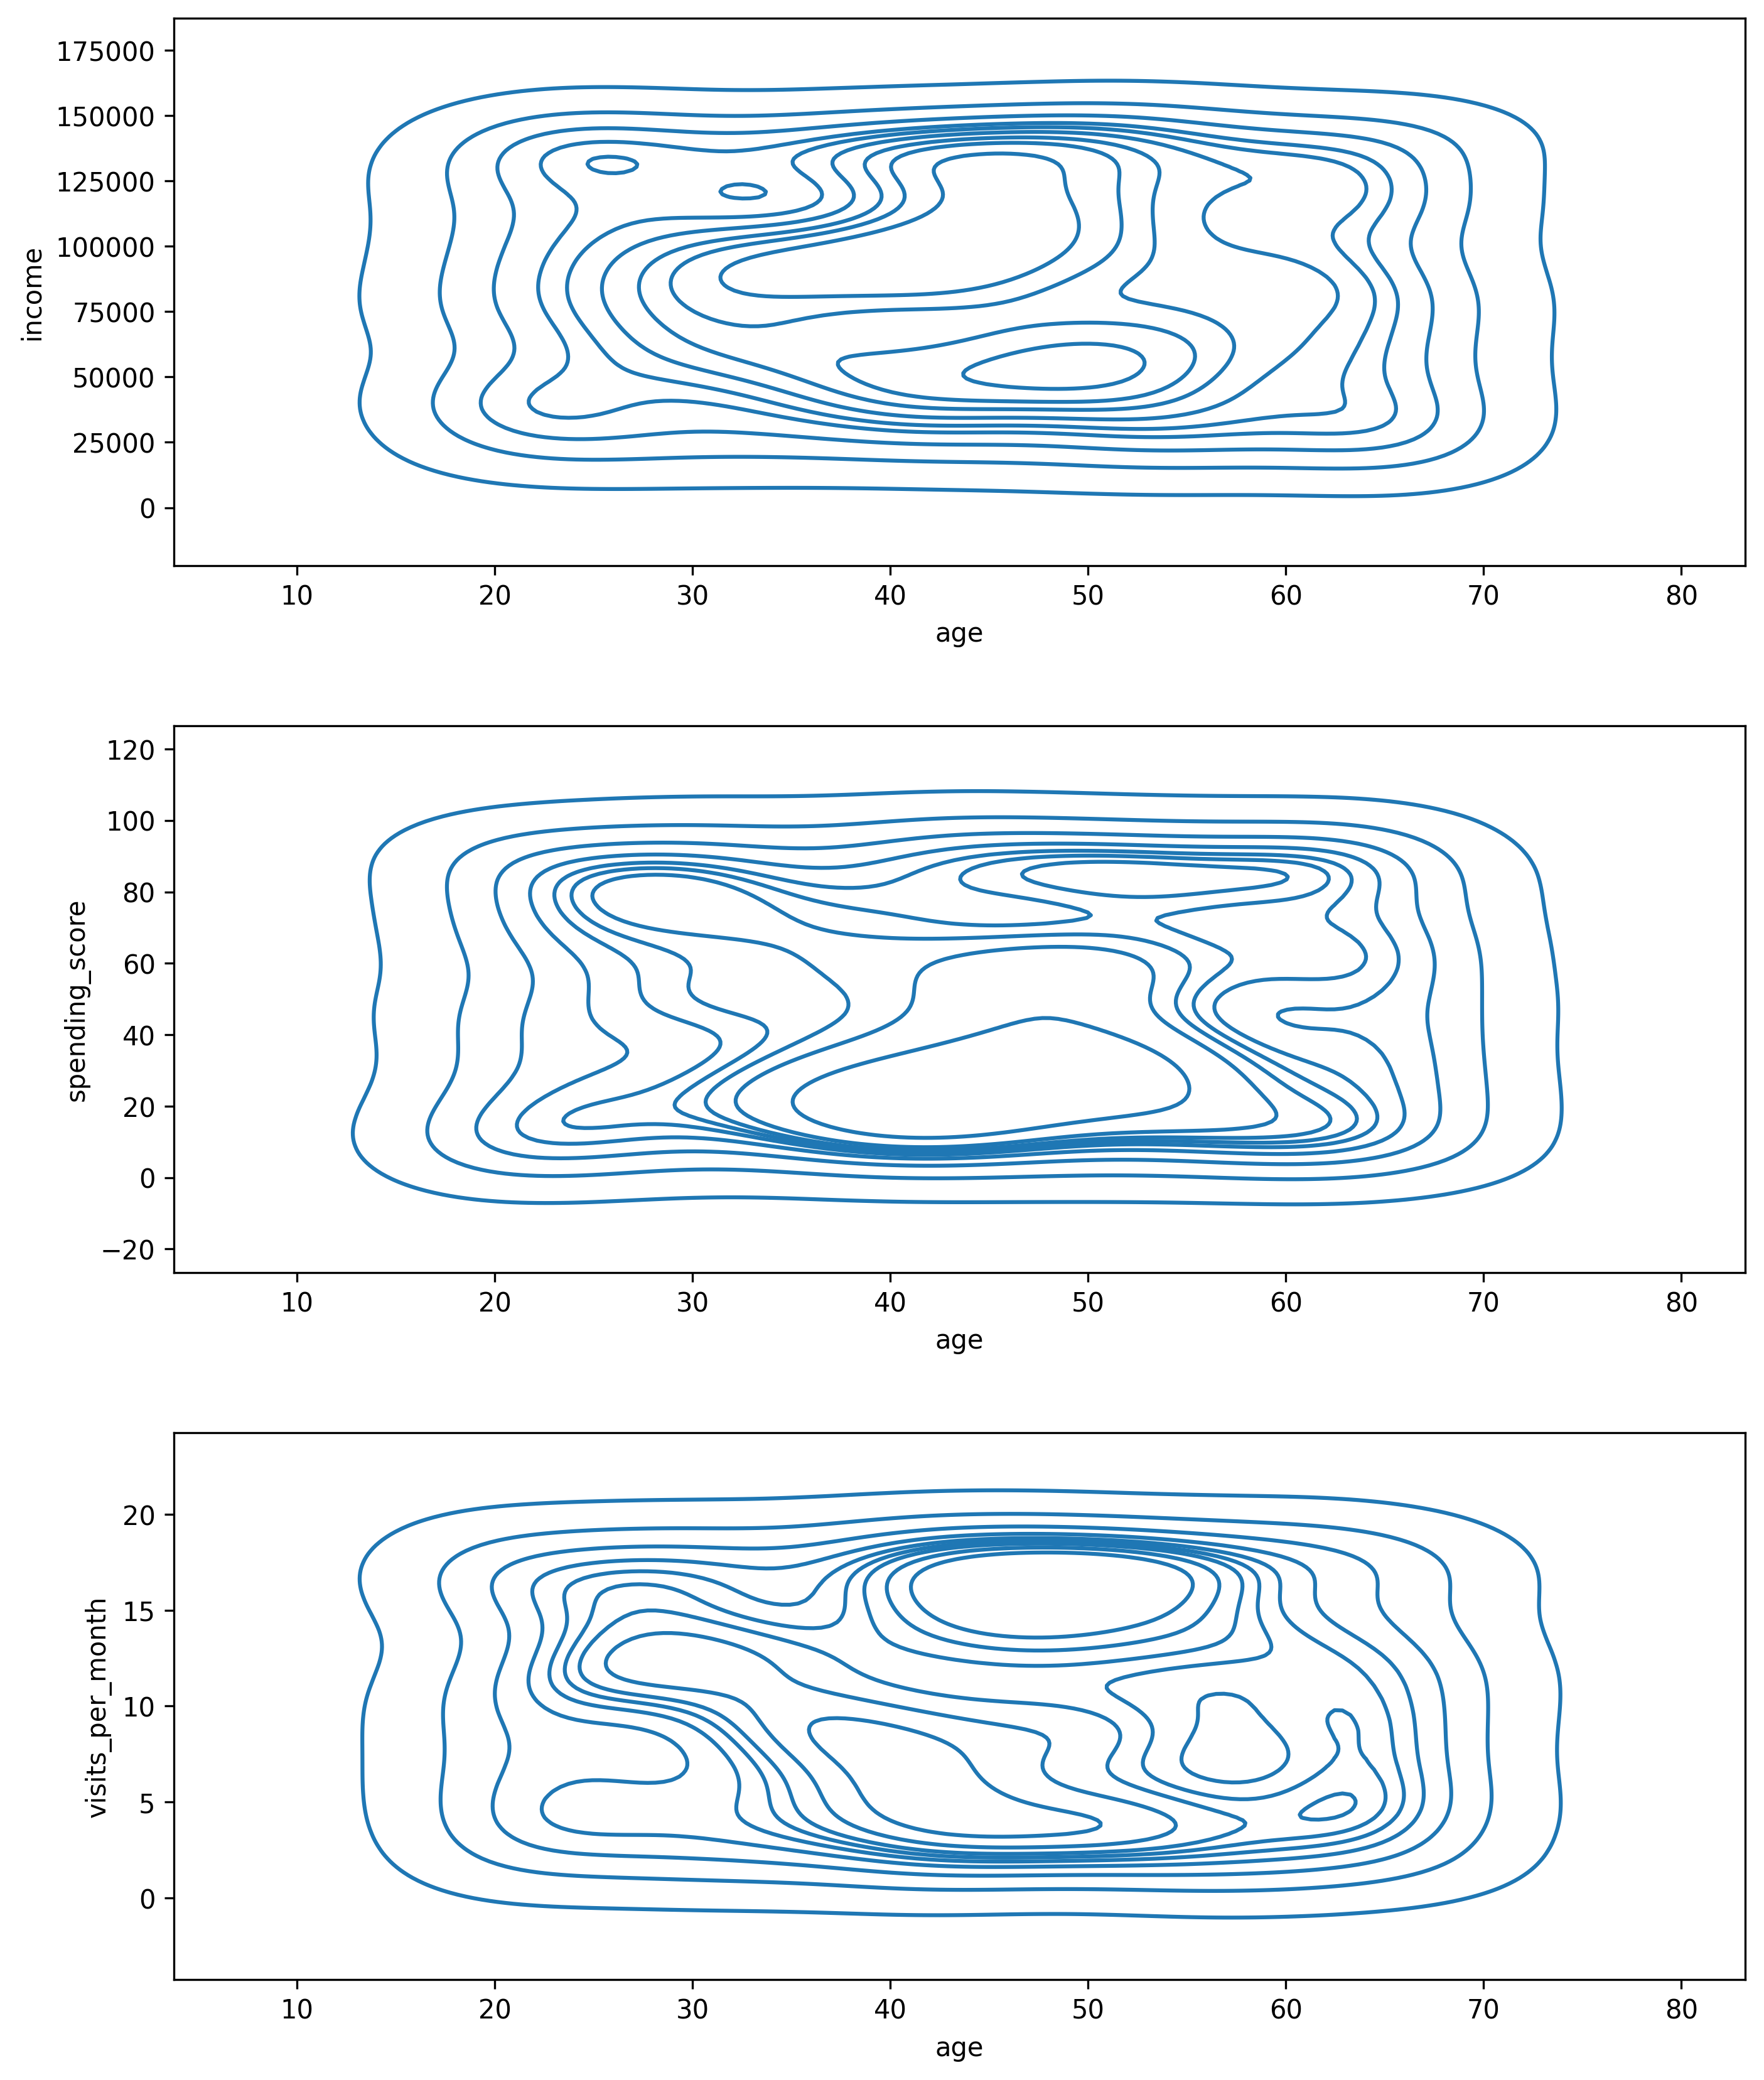

In [56]:
features = ["income", "spending_score", "visits_per_month"]
plt.figure(figsize=(10,15), dpi=300)
for i, var_x in enumerate(features):
    plt.subplot(4, 1, i+1)
    sns.kdeplot(df, x = "age", y = var_x)

plt.tight_layout(pad=3)
plt.show()
features = ["age", "income", "spending_score", "visits_per_month"]

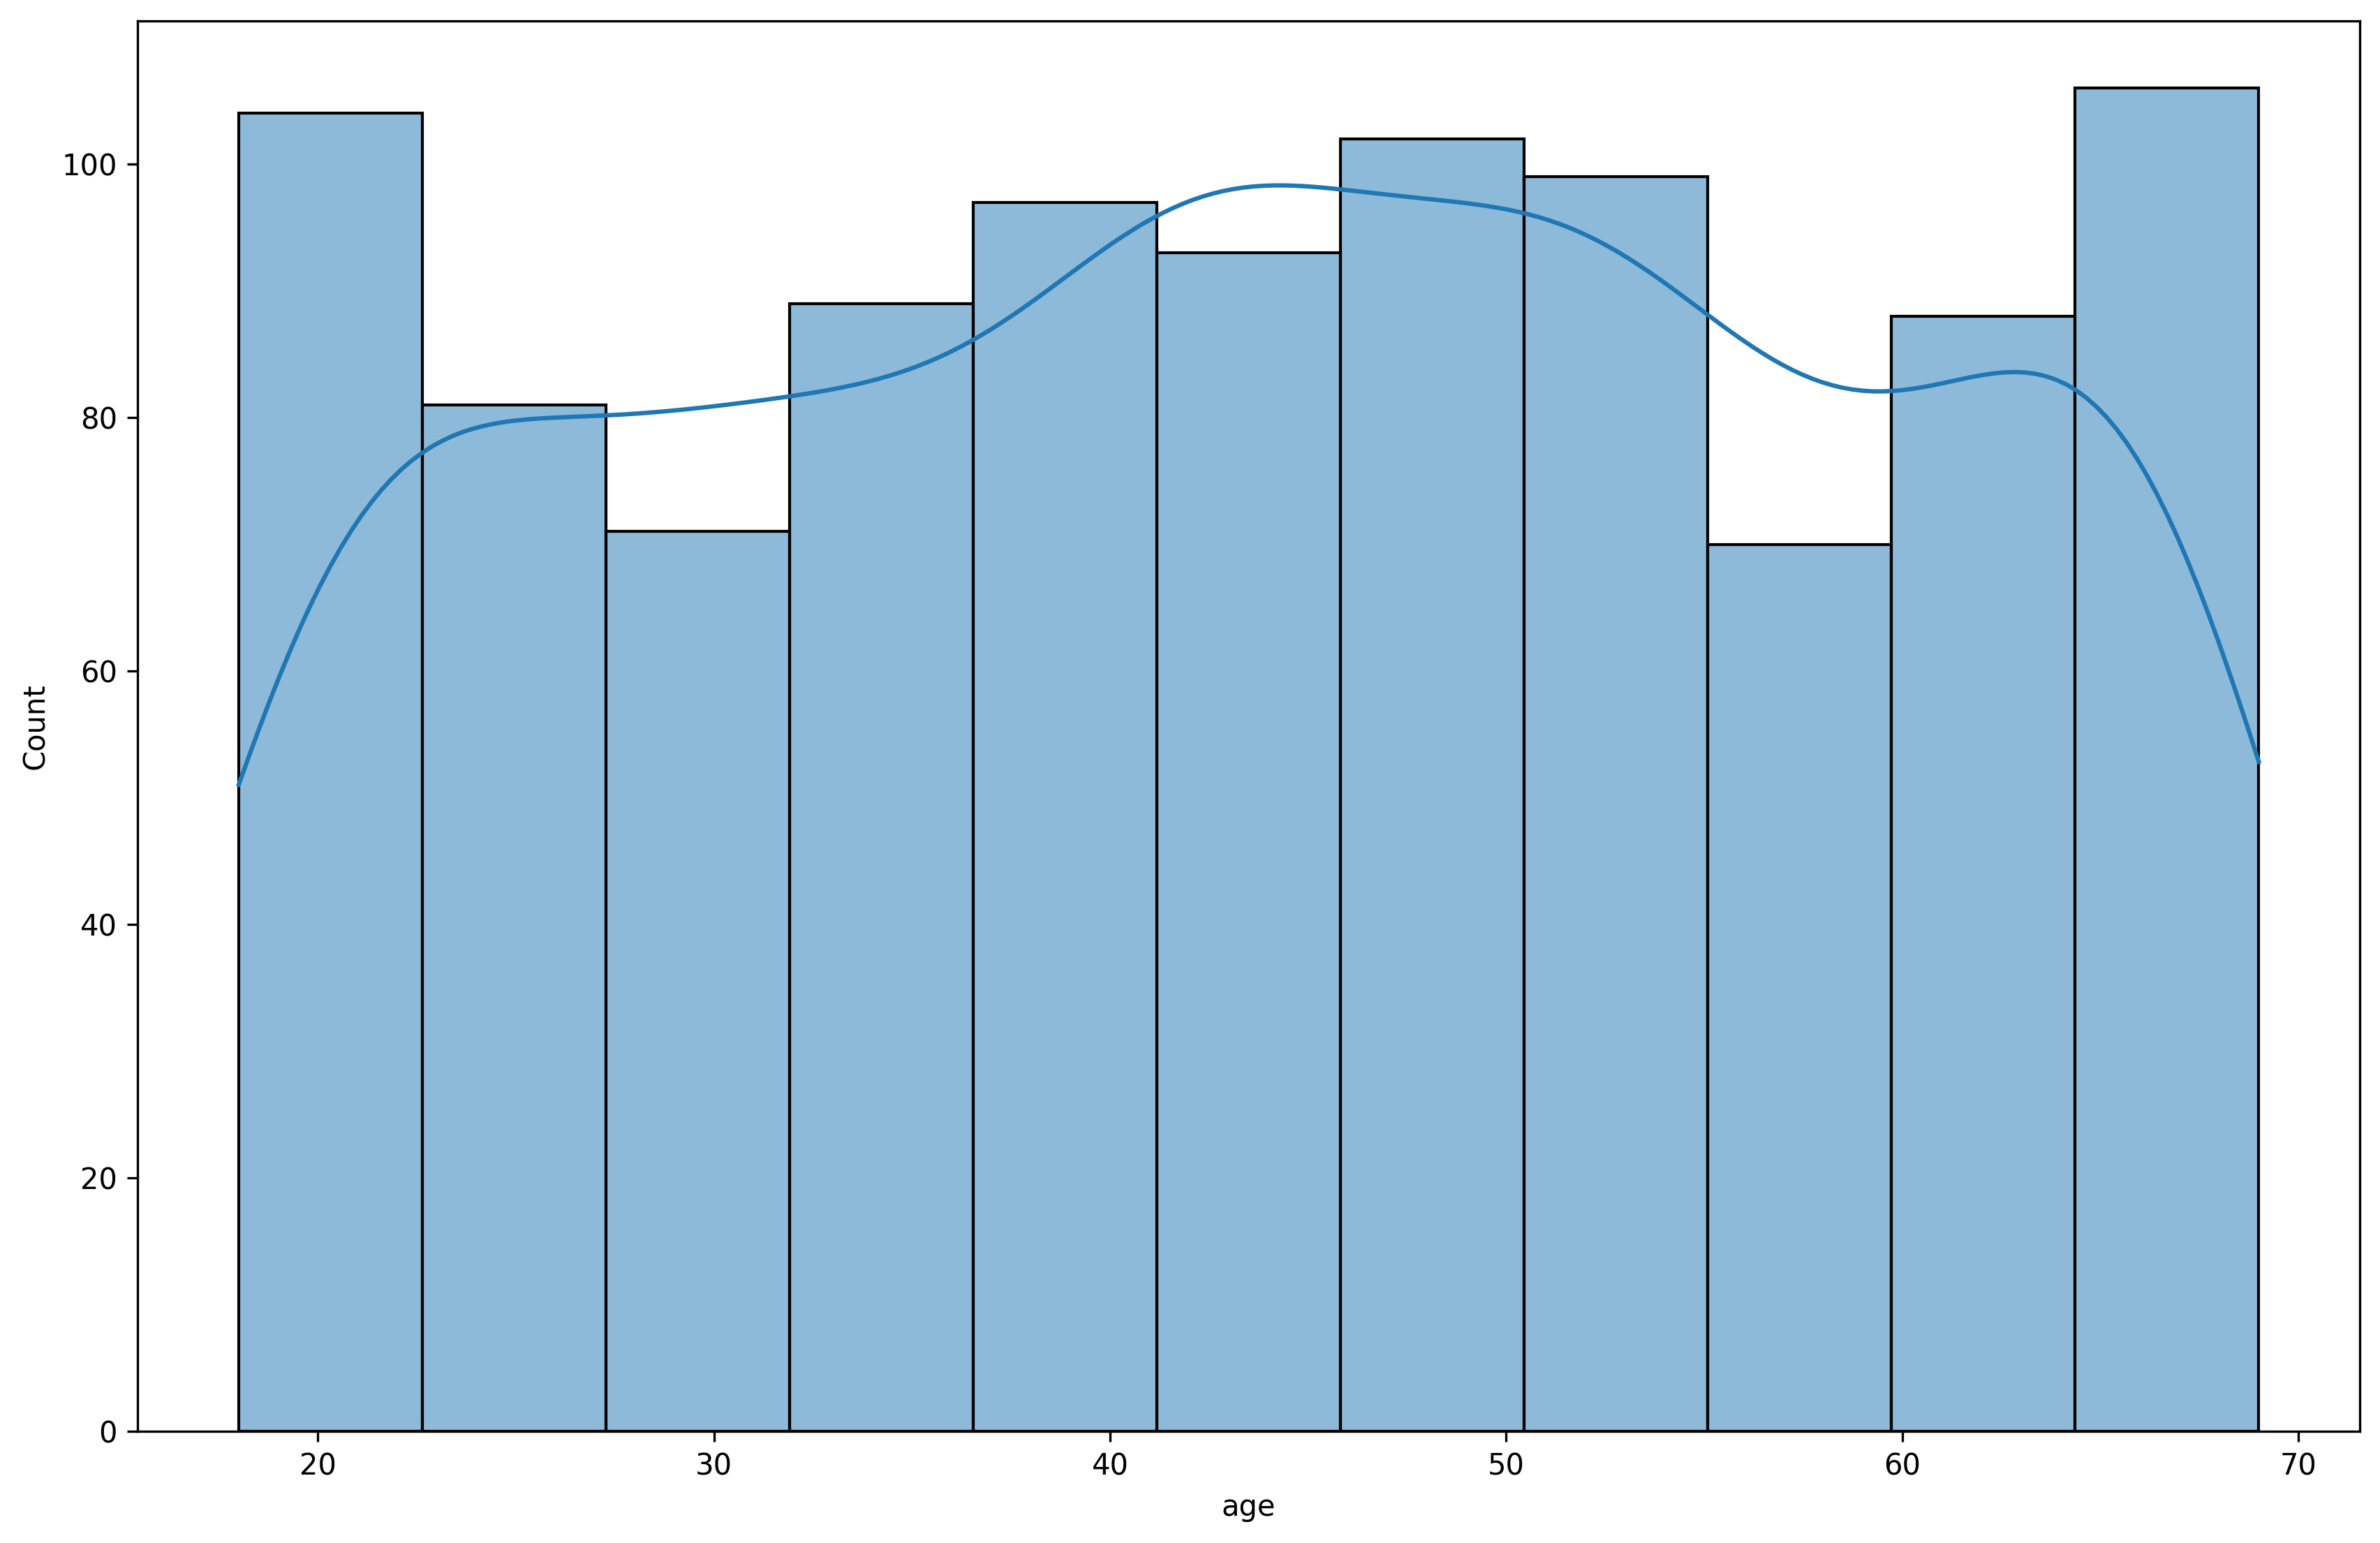

In [57]:
plt.figure(figsize=(12,8), dpi=300)
sns.histplot(df, x="age", kde=True)
plt.tight_layout(pad=3)
plt.show()

<Axes: xlabel='age', ylabel='Density'>

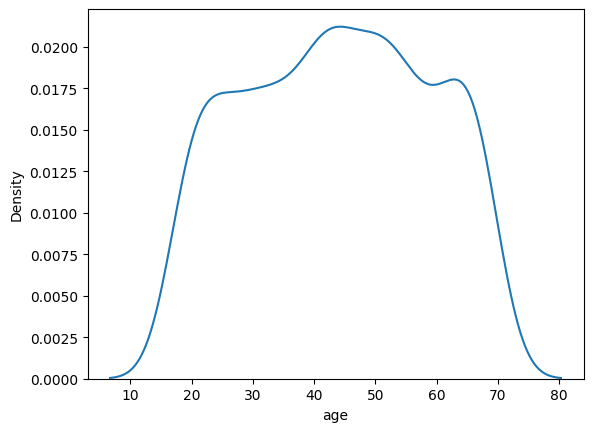

In [58]:
sns.kdeplot(df, x="age")

In [59]:
df.head()

,age,income,spending_score,visits_per_month
0,56,120186,55,9
1,69,49674,80,1
2,46,61271,62,8
3,32,88688,30,6
4,60,126076,55,6


In [60]:
from sklearn.model_selection import train_test_split

x_train, x_test = train_test_split(df, random_state=42)

In [61]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=8, random_state=42)

model.fit(x_train)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x_train)

model_scaled = KMeans(n_clusters=8, random_state=42)

model_scaled.fit(x_scaled)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [63]:
model.cluster_centers_

array([[4.31298701e+01, 1.09228636e+05, 4.91688312e+01, 1.08831169e+01],
       [4.55764706e+01, 2.35187176e+04, 5.05294118e+01, 9.61176471e+00],
       [4.41222222e+01, 6.11152333e+04, 4.53444444e+01, 9.81111111e+00],
       [4.36396396e+01, 1.42334775e+05, 5.17837838e+01, 9.60360360e+00],
       [4.33125000e+01, 7.70645625e+04, 4.51625000e+01, 1.09375000e+01],
       [4.29083333e+01, 4.33741917e+04, 4.61833333e+01, 1.03166667e+01],
       [4.50116279e+01, 1.24850872e+05, 5.21279070e+01, 9.95348837e+00],
       [4.31782178e+01, 9.27548416e+04, 4.87029703e+01, 1.03069307e+01]])

In [64]:
model_scaled.cluster_centers_

array([[ 0.90589864,  0.84059586, -0.83698351,  0.50244724],
       [ 0.76598448, -0.98661865, -0.6077872 , -0.90316919],
       [-1.08588616, -0.93930475,  0.36910282, -0.68095359],
       [ 0.79951759, -0.72550061,  0.96456496,  0.6698809 ],
       [-0.73628598,  0.72300498,  0.98022995,  0.70331584],
       [-0.35892686, -0.6348338 , -0.84748204,  1.02770001],
       [-0.8014344 ,  0.6190104 , -0.83072495, -0.68273745],
       [ 0.55624245,  0.92294814,  0.74017062, -0.85234487]])

In [65]:
model.feature_names_in_

array(['age', 'income', 'spending_score', 'visits_per_month'],
      dtype=object)

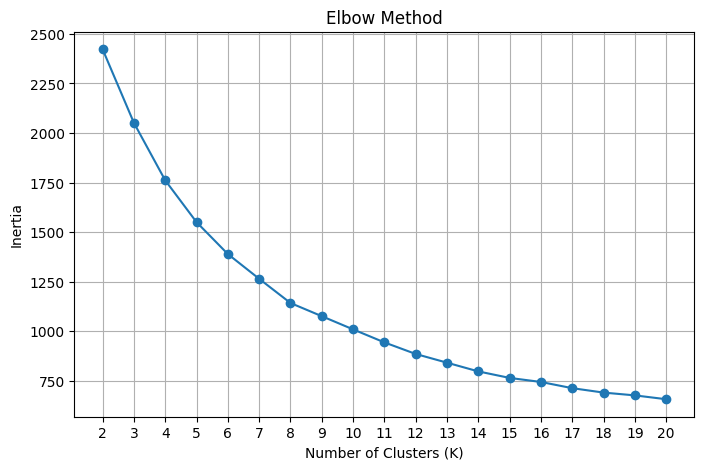

In [70]:
# We test different values of K and calculate
# Within-Cluster Sum of Squares (inertia).

inertia = []

K_range = range(2, 21)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(x_scaled)

    inertia.append(kmeans.inertia_)


# Plot elbow curve

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(K_range)

plt.grid(True)

plt.show()


In [71]:
from sklearn.metrics import silhouette_score

K = 2 | Silhouette Score = 0.1890
K = 3 | Silhouette Score = 0.1868
K = 4 | Silhouette Score = 0.2038
K = 5 | Silhouette Score = 0.2050
K = 6 | Silhouette Score = 0.2115
K = 7 | Silhouette Score = 0.2156
K = 8 | Silhouette Score = 0.2256
K = 9 | Silhouette Score = 0.2205
K = 10 | Silhouette Score = 0.2132
K = 11 | Silhouette Score = 0.2176
K = 12 | Silhouette Score = 0.2204
K = 13 | Silhouette Score = 0.2192
K = 14 | Silhouette Score = 0.2138
K = 15 | Silhouette Score = 0.2129
K = 16 | Silhouette Score = 0.2119
K = 17 | Silhouette Score = 0.2141
K = 18 | Silhouette Score = 0.2120
K = 19 | Silhouette Score = 0.2077
K = 20 | Silhouette Score = 0.2144


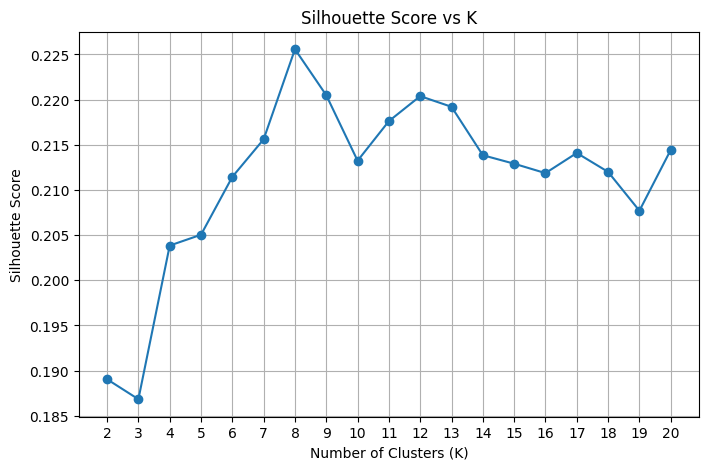

In [73]:
silhouette_scores = []

K_range = range(2, 21)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(x_scaled)

    score = silhouette_score(
        x_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k} | "
        f"Silhouette Score = {score:.4f}"
    )


# Plot silhouette scores

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")

plt.xticks(K_range)

plt.grid(True)

plt.show()

In [74]:
best_k = K_range[
    np.argmax(silhouette_scores)
]

print("\nBest K according to silhouette score:", best_k)



Best K according to silhouette score: 8


In [75]:
print("\nCluster centers in scaled space:")

print(kmeans.cluster_centers_)


# ------------------------------------------------------------
# 17. CONVERT CLUSTER CENTERS BACK TO ORIGINAL SCALE
# ------------------------------------------------------------

cluster_centers_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=df.columns
)

print("\nCluster centers in original feature scale:")

print(cluster_centers_df)


Cluster centers in scaled space:
[[-1.32220526 -1.24425061  0.61244438 -0.74681199]
 [-0.68319894 -0.72396884  0.9508915   0.97200527]
 [ 0.6926627   0.88029077 -0.95014993 -0.93444062]
 [ 0.397297   -0.99245675 -0.87676556 -1.10372335]
 [-1.17443839 -0.58145382 -0.94835847  0.77896808]
 [ 1.10772469  0.06895431  0.99635671  0.68756423]
 [ 1.19975737 -0.11298667 -0.89578188  0.34584887]
 [-0.6767405   0.19588981  0.51367515 -1.21427533]
 [ 0.33564832 -0.84992419  1.20763146 -0.39031759]
 [-1.19757729  0.75627793  0.51779497  1.24205151]
 [-0.88814656  0.97365913  1.17336201 -0.13639351]
 [-1.11559107  1.12256765 -0.80625035 -0.30826729]
 [ 1.06104783 -0.54918346  0.55349231 -1.29718931]
 [ 1.11499043 -1.28712495  0.73875273  1.13624981]
 [ 1.23637669 -1.37656038 -0.18154521 -0.33953277]
 [-0.95413023 -0.50222731 -0.95853672 -0.94739593]
 [ 0.45472469  1.11025001  0.86804963  1.02146109]
 [ 0.47036742  1.04845109 -0.99171944  0.96366298]
 [ 0.3083859  -0.75957975 -0.89066997  1.1695017

In [76]:
cluster_centers_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=df.columns
)

print("\nCluster centers in original feature scale:")

print(cluster_centers_df)


Cluster centers in original feature scale:
          age         income  spending_score  visits_per_month
0   24.310345   35418.586207       66.241379          6.034483
1   33.733333   55835.822222       75.977778         15.511111
2   54.022222  118791.222222       21.288889          5.000000
3   49.666667   45299.644444       23.400000          4.066667
4   26.489362   61428.489362       21.340426         14.446809
5   60.142857   86952.228571       77.285714         13.942857
6   61.500000   79812.382353       22.852941         12.058824
7   33.828571   91933.514286       63.400000          3.457143
8   48.757576   50893.000000       83.363636          8.000000
9   26.148148  113924.629630       63.518519         17.000000
10  30.711111  122455.244444       82.377778          9.400000
11  27.357143  128298.809524       25.428571          8.452381
12  59.454545   62694.863636       64.545455          3.000000
13  60.250000   33736.083333       69.875000         16.416667
14  62.0400